# **Wildebeest Popoulation In Serengeti National Park**

## Exact solution function

Exact Population at t = 40 years (2000): 1061.9248210832336 thousand
Exact Population at t = 0 years: 200.0 thousand
Exact Population at t = 5 years: 277.3771069500511 thousand
Exact Population at t = 10 years: 374.49846344996024 thousand
Exact Population at t = 15 years: 489.35315000545063 thousand
Exact Population at t = 17 years: 539.0535432435241 thousand
Exact Population at t = 20 years: 615.9879631375248 thousand
Exact Population at t = 25 years: 745.2658173632121 thousand
Exact Population at t = 30 years: 867.274485529497 thousand
Exact Population at t = 35 years: 974.1802192315462 thousand
Exact Population at t = 38 years: 1029.2204454872206 thousand
Exact Population at t = 40 years: 1061.9248210832336 thousand


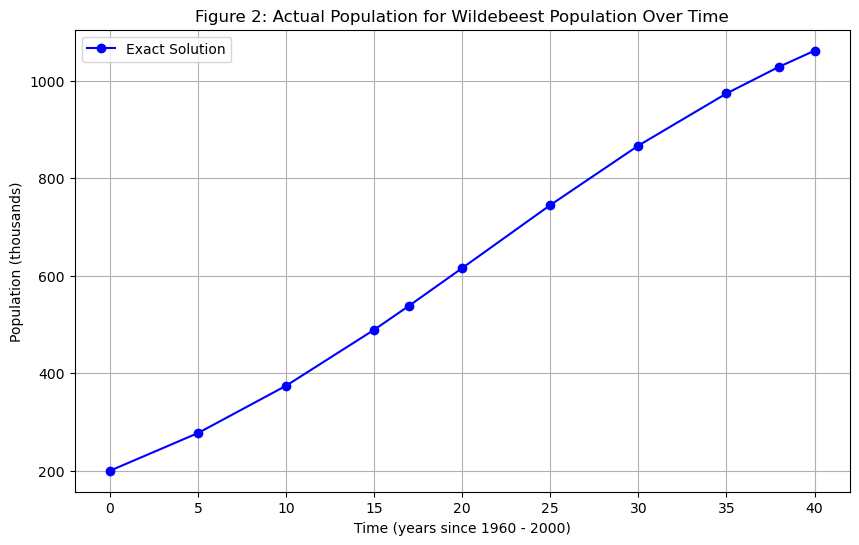

In [54]:
import math

# Exact solution function
def exact_solution(t: float, y0: float, r: float, K: float) -> float:
    """Computes the exact solution for the logistic growth model at time t."""
    return (K * y0 * math.exp(r * t)) / (K + y0 * (math.exp(r * t) - 1))

# Parameters for the model
t_initial = 0       # Start year (1960 as year 0)
t_final = 40       # End year (2000 as year 40)
r = 0.08            # Growth rate (8%)
K = 1300            # Carrying capacity in thousands
y_initial = 200     # Initial population in thousands

# Calculate the exact solution for the final time
exact_population = exact_solution(t_final, y_initial, r, K)
print(f"Exact Population at t = {t_final} years (2000): {exact_population} thousand")

time_steps = [0, 5, 10, 15, 17, 20, 25, 30, 35, 38, 40]  # Years to evaluate
exact_populations = []  # Store populations for plotting

for t in time_steps:
    population = exact_solution(t, y_initial, r, K)
    exact_populations.append(population)
    print(f"Exact Population at t = {t} years: {population} thousand")

# Plotting the exact solution over time - USED IA to generate the plot:)
plt.figure(figsize=(10, 6))
plt.plot(time_steps, exact_populations, marker='o', linestyle='-', color='blue', label='Exact Solution')
plt.xlabel('Time (years since 1960 - 2000)')
plt.ylabel('Population (thousands)')
plt.title('Figure 2: Actual Population for Wildebeest Population Over Time')
plt.legend()
plt.grid(True)
plt.show()

## Euler Method Implementation

In [91]:
# Logistic growth function -> USED PROFESSOR CODE FROM PREVIOUS CLASS 
def logistic_growth(r: float, y: float, K: float) -> float:
    """Logistic growth model, returns the derivative of y."""
    return r * y * (1 - y / K)

# Differential function that uses logistic growth
def differential(t: float, y: float) -> float:
    """Specific growth model, returns the derivative of y."""
    K = 1300.0  # Carrying capacity in thousands
    r = 0.08   # Growth rate (8%)
    return logistic_growth(r, y, K)

# Euler step function - USED PROFESSOR CODE FROM CLASS 
def euler_step(y_prev: float, h: float, t: float, f: callable) -> float:
    """Returns the value of the next step using the Euler method."""
    slope = f(t, y_prev)  # Now using f as the function to calculate the slope
    y_next = y_prev + h * slope
    return y_next

# Euler method to iterate over multiple steps with different step sizes - USED PROFESSOR CODE FROM CLASS 
def euler_method(y_initial: float, t_initial: float, t_final: float, steps: int, f: callable) -> float:
    """Returns the final y value using the Euler method for the logistic growth model."""
    h = (t_final - t_initial) / steps  # Step size
    y = y_initial
    t = t_initial
    y_values = [y_initial]

    for i in range(steps):
        y = euler_step(y, h, t, f)
        t += h
        y_values.append(y)
        
    final_pop = y_values[-1]
    print(f"\nResults for {steps} steps:")
    print(f"Final Population = {final_pop}")
    return final_pop

# Parameters
t_initial = 0        # 1960 as year 0
t_final = 40         # 2000 as year 40
y_initial = 200      # Initial population in thousands

# Different step sizes to observe improvement
step_sizes = [100000, 100, 50, 10, 1]

euler_results = []

# Run the Euler method and store results 
for steps in step_sizes:
    population_euler = euler_method(y_initial, t_initial, t_final, steps, differential)
    error_euler = abs(exact_population - population_euler)
    # Store each result as a formatted string - for the error later 
    euler_results.append(f"Step size {steps}: Fin_Pop = {population_euler}, Error = {error_euler}")


Results for 100000 steps:
Final Population = 1061.924388421509

Results for 100 steps:
Final Population = 1061.4743704864125

Results for 50 steps:
Final Population = 1060.987462501569

Results for 10 steps:
Final Population = 1055.5904608479468

Results for 1 steps:
Final Population = 741.5384615384615


## Runge-Kutta Method Implementation

In [90]:
# Define the logistic growth function -> USED PROFESSOR CODE FROM PREVIOUS CLASS 
def rk4_step(y_n: float, t_n: float, h: float, f: callable) -> float:
    """Performs one step of the 4th-order Runge-Kutta (RK4) method."""
    k1 = f(t_n, y_n)
    k2 = f(t_n + h / 2, y_n + (h / 2) * k1)
    k3 = f(t_n + h / 2, y_n + (h / 2) * k2)
    k4 = f(t_n + h, y_n + h * k3)
    
    y_next = y_n + (h / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    return y_next

# RK4 method to iterate over multiple steps with different step sizes
def rk4_method(y_initial: float, t_initial: float, t_final: float, steps: int, f: callable) -> float:
    """Returns the final y value using the RK4 method for the logistic growth model."""
    h = (t_final - t_initial) / steps  # Step size
    y = y_initial
    t = t_initial

    for _ in range(steps):
        y = rk4_step(y, t, h, f)
        t += h

    #print(f"Final Population after {steps} steps: {y}")
    return y

# Parameters for the simulation
t_initial = 0       # 1960 as year 0
t_final = 40        # 2000 as year 17
y_initial = 200     # Initial population in thousands

# Different step sizes to observe improvement
step_sizes = [10000, 100, 50, 10, 1]

# Running the RK4 method with various step sizes for the adjusted time period
for steps in step_sizes:
    final_population = rk4_method(y_initial, t_initial, t_final, steps, differential)
    print(f"Step size {steps}:Final Population = {final_population}")


Step size 10000:Final Population = 1061.9248210832334
Step size 100:Final Population = 1061.9248200803627
Step size 50:Final Population = 1061.9248050747196
Step size 10:Final Population = 1061.9150045630606
Step size 1:Final Population = 988.0972030128831


## ERROR CALCULATION

#### Euler Method Error 

In [92]:
print("Euler Method Errors:")
for result in euler_results:
    print(result)

Euler Method Errors:
Step size 100000: Fin_Pop = 1061.924388421509, Error = 0.0004326617245169473
Step size 100: Fin_Pop = 1061.4743704864125, Error = 0.45045059682115607
Step size 50: Fin_Pop = 1060.987462501569, Error = 0.9373585816645118
Step size 10: Fin_Pop = 1055.5904608479468, Error = 6.334360235286795
Step size 1: Fin_Pop = 741.5384615384615, Error = 320.38635954477206


#### Runge-Kutta Method

In [88]:
rk4_results = []

for steps in step_sizes:
    final_population_rk4 = rk4_method(y_initial, t_initial, t_final, steps, differential)
    error_rk4 = abs(exact_population - final_population_rk4)
    rk4_results.append(f"Step size {steps}: Fin_Pop = {final_population_rk4}, Error = {error_rk4}")

# Print the final formatted output without intermediate prints
print("\nRK4 Method Errors:")
for result in rk4_results:
    print(result)


RK4 Method Errors:
Step size 100000: Fin_Pop = 1061.9248210832272, Error = 6.366462912410498e-12
Step size 100: Fin_Pop = 1061.9248200803627, Error = 1.0028709311882267e-06
Step size 50: Fin_Pop = 1061.9248050747196, Error = 1.6008513966880855e-05
Step size 10: Fin_Pop = 1061.9150045630606, Error = 0.00981652017298984
Step size 1: Fin_Pop = 988.0972030128831, Error = 73.82761807035047


#### Error Plot of both Method 


Results for 100000 steps:
Final Population = 1061.924388421509

Results for 100 steps:
Final Population = 1061.4743704864125

Results for 50 steps:
Final Population = 1060.987462501569

Results for 10 steps:
Final Population = 1055.5904608479468

Results for 1 steps:
Final Population = 741.5384615384615


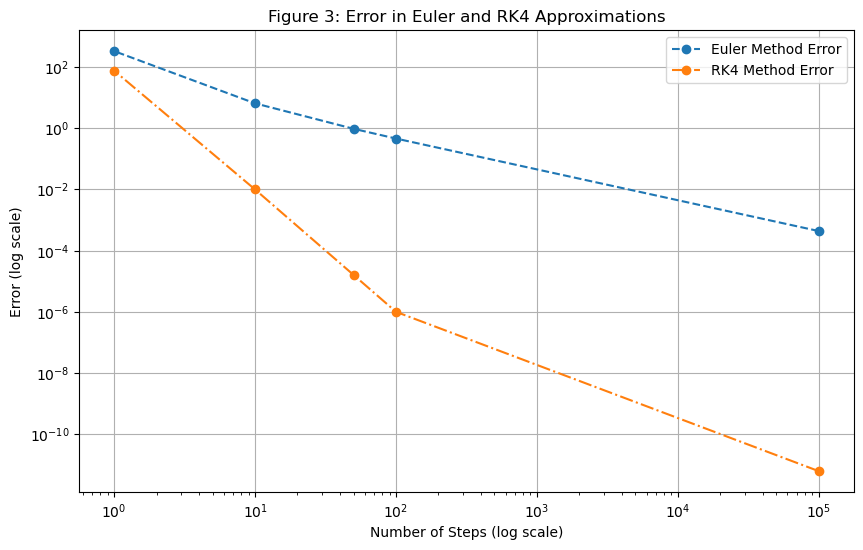

In [86]:
#USED IA TO GENERATE THE ERROR PLOT.
import matplotlib.pyplot as plt
euler_errors = []
rk4_errors = []

# Calculate errors for each step size
for steps in step_sizes:
    population_euler = euler_method(y_initial, t_initial, t_final, steps, differential)
    population_rk4 = rk4_method(y_initial, t_initial, t_final, steps, differential)
    
    euler_error = abs(exact_population - population_euler)
    rk4_error = abs(exact_population - population_rk4)
    
    euler_errors.append(euler_error)
    rk4_errors.append(rk4_error)


plt.figure(figsize=(10, 6))
plt.plot(step_sizes, euler_errors, label='Euler Method Error', marker='o', linestyle='--')
plt.plot(step_sizes, rk4_errors, label='RK4 Method Error', marker='o', linestyle='-.')

plt.xscale('log')  # Log scale for step sizes
plt.yscale('log')  # Log scale for error values
plt.xlabel('Number of Steps (log scale)')
plt.ylabel('Error (log scale)')
plt.title('Figure 3: Error in Euler and RK4 Approximations')
plt.legend()
plt.grid(True)
plt.show()